# Data Exploration and Feature Engineering

Explore PFR training data and define **inputs** (`df_features`) and **outputs** (`df_target`) for ML. Run cells in order.


## 1. Setup

Import libraries and set plot style. **Run this cell first.**


In [1]:
import os
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def rows_at_inlet_plane(df: pd.DataFrame) -> pd.DataFrame:
    """Rows at z=0 / relative_position=0 (one per simulation). Avoids EDA counting every axial point."""
    if df is None or len(df) == 0:
        return df
    if 'relative_position' in df.columns:
        return df.loc[df['relative_position'].abs() < 1e-9].copy()
    if 'z_position_m' in df.columns:
        return df.loc[df['z_position_m'].abs() < 1e-12].copy()
    return df.copy()


def rows_at_exit_plane(df: pd.DataFrame) -> pd.DataFrame:
    """One row per simulation at the reactor exit (max z in that run)."""
    if df is None or len(df) == 0:
        return df
    if 'z_position_m' not in df.columns:
        return df.copy()
    group_cols = [c for c in (
        'reactant_type', 'initial_temperature_K', 'initial_pressure_Pa',
        'reactor_length_m', 'reactor_diameter_m', 'mass_flow_rate_kgps', 'heat_flux_Wm2',
    ) if c in df.columns]
    if group_cols:
        idx = df.groupby(group_cols, sort=False)['z_position_m'].idxmax()
        return df.loc[idx].copy()
    if 'relative_position' in df.columns:
        return df.loc[(df['relative_position'] - 1.0).abs() < 1e-8].copy()
    if 'reactor_length_m' in df.columns:
        dz = (df['z_position_m'] - df['reactor_length_m']).abs()
        return df.loc[dz < 1e-9].copy()
    return df.loc[[df['z_position_m'].idxmax()]].copy()


# Project root resolution (notebook lives in notebooks/)
_cwd = Path(os.getcwd())
project_root = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.utils.plot_style import setup_matplotlib
from src.ml.dataframe_pickle import load_dataframe_pickle, save_pickle_portable

setup_matplotlib()

print("Libraries imported successfully.")

Libraries imported successfully.


**Config.** After the setup cell, all paths use `project_root` (repo root). Toggle `IF_LOAD_DATA`, `PRINT_ON_SCREEN`, `IF_EXPORT_FEATURES_TARGETS`. Use `IF_PIN_SPECIFIC_FILES` to load a fixed `training_data_complete_*.pkl` / `metadata_*.json` instead of the latest in `data/training/`.

In [2]:
PRINT_ON_SCREEN = True
IF_LOAD_DATA    = True

# After setup cell: cwd is project_root — use repo paths (not ../data/... which leaves the project).
BASE_DIR_ALL = str(project_root / "data" / "training")
EXPORT_DIR   = str(project_root / "data" / "processed")

# Latest files in BASE_DIR_ALL, or pin a specific run:
IF_PIN_SPECIFIC_FILES = False
PIN_CORE_DATA_FILE = "training_data_complete_XXXXXXXX.pkl"  # used only if IF_PIN_SPECIFIC_FILES
PIN_META_DATA_FILE = "metadata_XXXXXXXXXXX.json"

_data_files = sorted(Path(BASE_DIR_ALL).glob("training_data_complete_*.pkl"), reverse=True)
_meta_files = sorted(Path(BASE_DIR_ALL).glob("metadata_*.json"), reverse=True)

if IF_PIN_SPECIFIC_FILES:
    CORE_DATA_FILE_NAME = PIN_CORE_DATA_FILE
    META_DATA_FILE_NAME = PIN_META_DATA_FILE
else:
    CORE_DATA_FILE_NAME = _data_files[0].name if _data_files else ""
    META_DATA_FILE_NAME = _meta_files[0].name if _meta_files else ""

IF_EXPORT_FEATURES_TARGETS      = True
EXPORT_FEATURES_TARGETS_FILE_NAME = f"features_targets_{CORE_DATA_FILE_NAME.replace('.pkl', '')}.pkl"

print(50*"=")
print('USER IO FLAGS:')
print(f'LOAD_DATA = {IF_LOAD_DATA}')
print(f'CORE DATA FILE NAME = {CORE_DATA_FILE_NAME}')
print(f'META DATA FILE NAME = {META_DATA_FILE_NAME}')
print(f'BASE DIR ALL = {BASE_DIR_ALL}')
print(f'IF_EXPORT_FEATURES_TARGETS = {IF_EXPORT_FEATURES_TARGETS}')
print(f'EXPORT_DIR = {EXPORT_DIR}')
print(f'EXPORT_FEATURES_TARGETS_FILE_NAME = {EXPORT_FEATURES_TARGETS_FILE_NAME}')
print(50*"=")

USER IO FLAGS:
LOAD_DATA = True
CORE DATA FILE NAME = training_data_complete_20260506_110946.pkl
META DATA FILE NAME = metadata_20260506_110946.json
BASE DIR ALL = c:\35 PYRO_MEANLINE\HydrAI\data\training
IF_EXPORT_FEATURES_TARGETS = True
EXPORT_DIR = c:\35 PYRO_MEANLINE\HydrAI\data\processed
EXPORT_FEATURES_TARGETS_FILE_NAME = features_targets_training_data_complete_20260506_110946.pkl


## 2. Load training data

Loads from paths above; populates `df_data` and optional `df_meta`.


In [3]:
# Paths: BASE_DIR_ALL is under project_root (see config cell). Uses os.path.join for Windows/Linux.
df_data = pd.DataFrame()
df_meta = {}

if IF_LOAD_DATA:
    print(50*"=")
    FILE_PATH_DATA = os.path.join(BASE_DIR_ALL, CORE_DATA_FILE_NAME)
    FILE_PATH_META = os.path.join(BASE_DIR_ALL, META_DATA_FILE_NAME)
    if os.path.isfile(FILE_PATH_DATA):
        df_data = load_dataframe_pickle(FILE_PATH_DATA)
        n_before = len(df_data)
        df_data = df_data.dropna()
        n_dropped = n_before - len(df_data)
        if n_dropped > 0:
            print(f'Dropped {n_dropped} rows with NaN ({n_before} -> {len(df_data)}).')
        if os.path.isfile(FILE_PATH_META):
            with open(FILE_PATH_META, 'r') as f:
                df_meta = json.load(f)
        print(f'Data loaded :\n{CORE_DATA_FILE_NAME}, \n{META_DATA_FILE_NAME}')
    else:
        print(f'File not found: {FILE_PATH_DATA}')

print(50*"=")

Data loaded :
training_data_complete_20260506_110946.pkl, 
metadata_20260506_110946.json


### 2.1 Data overview

Shape, unique `reactant_type`, and column list. Gated by **PRINT_ON_SCREEN**.


In [4]:
# Data exploration (only when we have data)
if len(df_data) == 0:
    print("No data loaded. Skip exploration or load data in the previous cell.")
elif PRINT_ON_SCREEN:
    print(50*"=")
    print("Dataframe shape:", df_data.shape[0], "rows and", df_data.shape[1], "columns")
    print(50*"")
    if 'reactant_type' in df_data.columns:
        print('Unique reactant types:', df_data['reactant_type'].unique())
    print(50*"")
    print("Dataframe columns:", df_data.columns.to_list())
    print(50*"=")
else:
    print("Data exploration output skipped (PRINT_ON_SCREEN=False).")

Dataframe shape: 2006 rows and 328 columns

Unique reactant types: ['n-Hexane']

Dataframe columns: ['reactant_type', 'initial_temperature_K', 'initial_pressure_Pa', 'reactor_length_m', 'reactor_diameter_m', 'mass_flow_rate_kgps', 'heat_flux_Wm2', 'z_position_m', 'relative_position', 'temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3', 'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK', 'mean_molecular_weight_kgkmol', 'enthalpy_Jkg', 'entropy_JkgK', 'internal_energy_Jkg', 'gibbs_free_energy_Jkg', 'viscosity_Pas', 'thermal_conductivity_WmK', 'Y_Water', 'X_Water', 'Y_Ar', 'X_Ar', 'Y_He', 'X_He', 'Y_Ne', 'X_Ne', 'Y_N2', 'X_N2', 'Y_C6H14(1)', 'X_C6H14(1)', 'Y_Benzene(2)', 'X_Benzene(2)', 'Y_C8H10(3)', 'X_C8H10(3)', 'Y_C4H6(4)', 'X_C4H6(4)', 'Y_C4H8(5)', 'X_C4H8(5)', 'Y_Toluene(6)', 'X_Toluene(6)', 'Y_Styrene(7)', 'X_Styrene(7)', 'Y_C2H4(8)', 'X_C2H4(8)', 'Y_C3H6(9)', 'X_C3H6(9)', 'Y_C5H6(10)', 'X_C5H6(10)', 'Y_C3H7(13)', 'X_C3H7(13)', 'Y_C4H9(14)', 'X_C4H9(14)', 'Y_C2H5(15)', 'X_C2

### 2.2 Input feature distributions

Histograms of the 6 swept operating parameters — confirms the sampling coverage (LHS / grid / random).

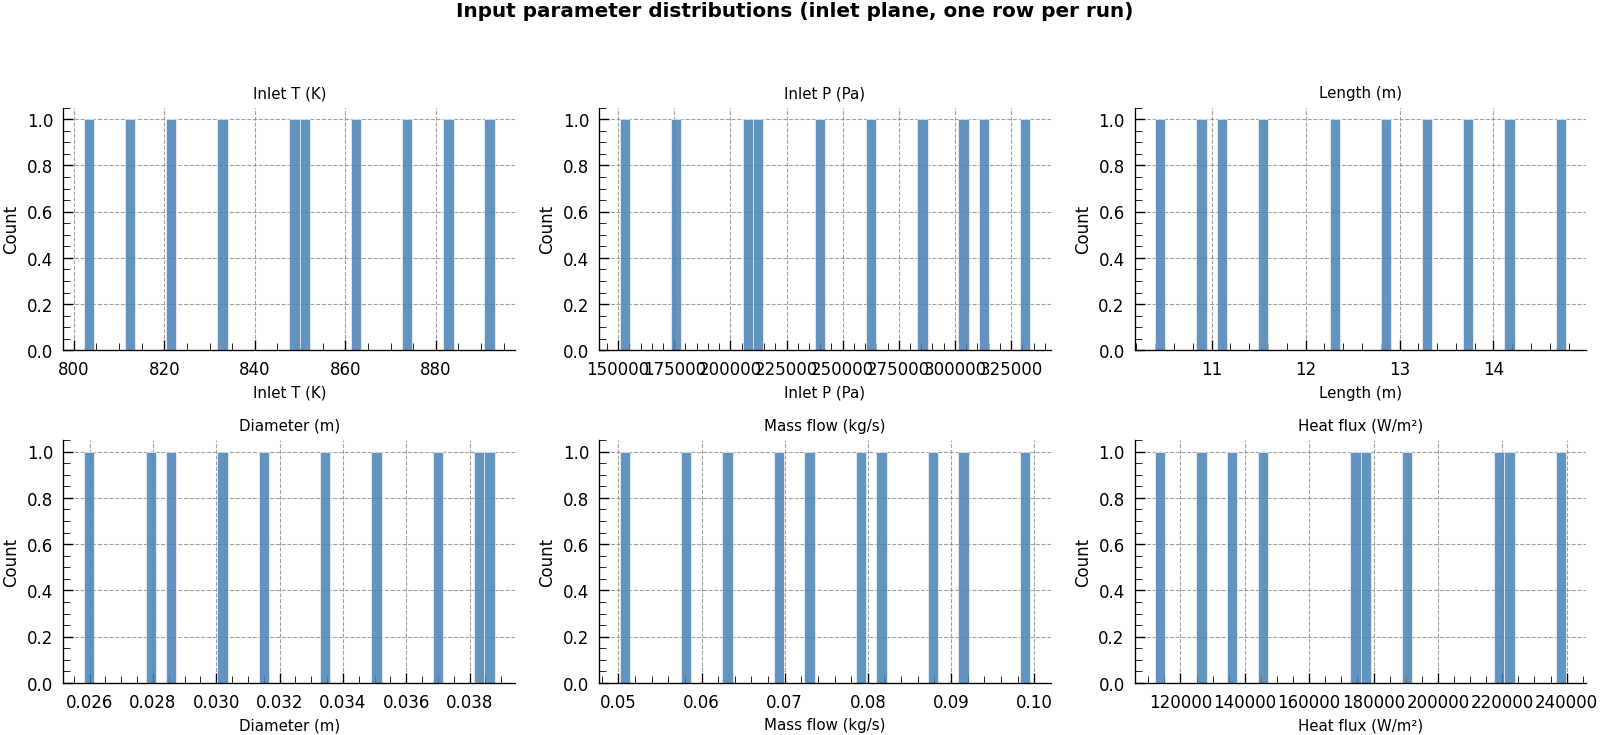

In [9]:
if len(df_data) > 0:
    df_eda = rows_at_inlet_plane(df_data)
    sweep_params = [
        ('initial_temperature_K',  'Inlet T (K)'),
        ('initial_pressure_Pa',    'Inlet P (Pa)'),
        ('reactor_length_m',       'Length (m)'),
        ('reactor_diameter_m',     'Diameter (m)'),
        ('mass_flow_rate_kgps',    'Mass flow (kg/s)'),
        ('heat_flux_Wm2',          'Heat flux (W/m²)'),
    ]
    sweep_params = [(c, l) for c, l in sweep_params if c in df_data.columns]

    if sweep_params:
        n_cols = min(3, len(sweep_params))
        n_rows = (len(sweep_params) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(4.5 * n_cols, 3.0 * n_rows),
            squeeze=False,
        )
        setup_matplotlib(axes)
        for ax, (col, label) in zip(axes.ravel(), sweep_params):
            ax.hist(df_eda[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
            ax.set_xlabel(label, fontsize=9)
            ax.set_ylabel('Count')
            ax.set_title(label, fontsize=9)
        for ax in axes.ravel()[len(sweep_params) :]:
            ax.set_visible(False)
        fig.suptitle('Input parameter distributions (inlet plane, one row per run)', fontweight='bold', y=1.04)
        plt.tight_layout()
        if IF_EXPORT_FEATURES_TARGETS:
            _fig_dir = Path(EXPORT_DIR).parent / 'figures' / 'eda'
            _fig_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(_fig_dir / 'input_distributions.png')
        plt.show()
        plt.close(fig)

### 2.3 Key output target statistics & distributions

Summary statistics for primary targets and key product species.

Primary target statistics (inlet plane):
                                      mean           std           min        median           max
temperature_K                 8.482524e+02     30.594191  8.022604e+02  8.502122e+02  8.929973e+02
pressure_Pa                   2.488999e+05  61326.967856  1.506498e+05  2.508542e+05  3.335448e+05
velocity_ms                   6.925119e+01     29.965654  3.371393e+01  6.959008e+01  1.252310e+02
density_kgm3                  1.463442e+00      0.366849  9.012316e-01  1.496938e+00  1.926773e+00
mean_molecular_weight_kgkmol  4.141080e+01      0.000000  4.141080e+01  4.141080e+01  4.141080e+01
heat_capacity_cp_JkgK         3.144192e+03     54.693921  3.060373e+03  3.148801e+03  3.222552e+03
heat_capacity_cv_JkgK         2.943412e+03     54.693921  2.859593e+03  2.948021e+03  3.021772e+03
enthalpy_Jkg                 -3.846498e+06  96169.525470 -3.989979e+06 -3.841081e+06 -3.704767e+06


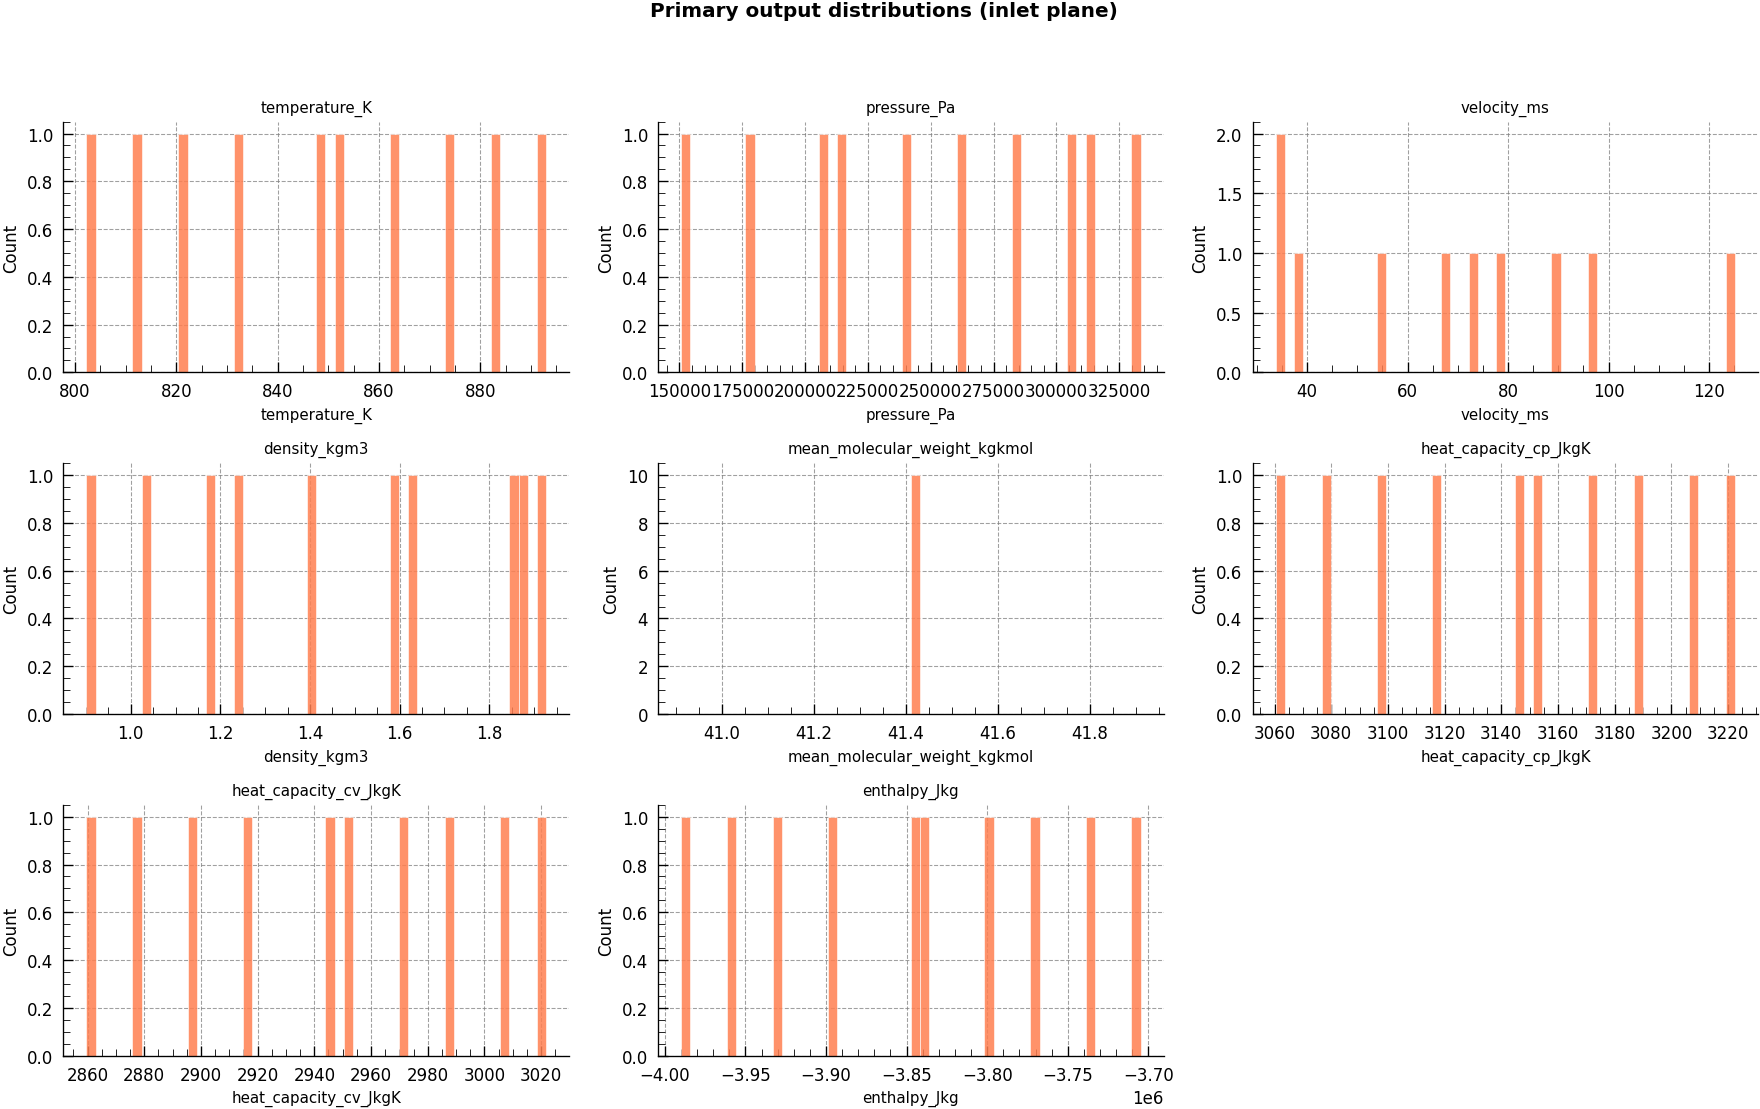

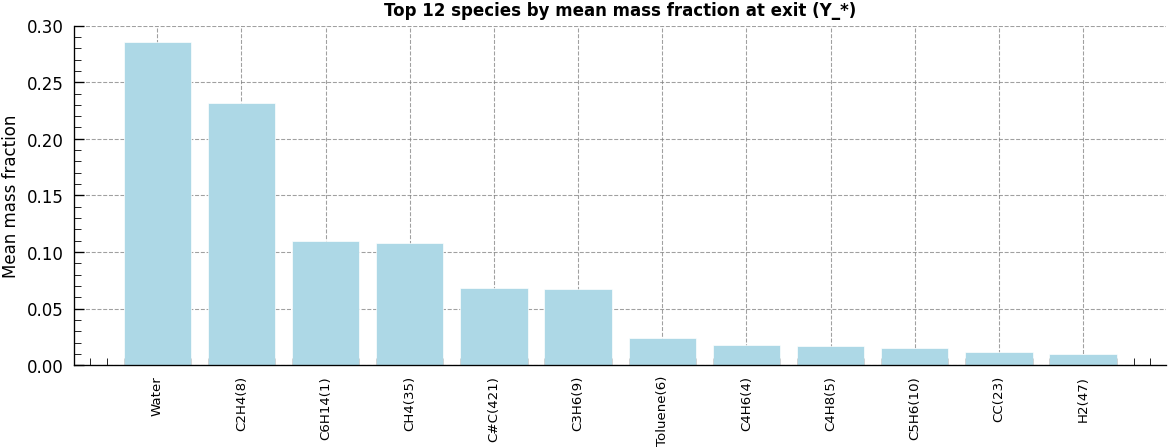


Top 12 species at exit (mean Y): {'Y_Water': 0.2857142857142855, 'Y_C2H4(8)': 0.2313027046754943, 'Y_C6H14(1)': 0.10950700254102848, 'Y_CH4(35)': 0.1083392843318685, 'Y_C#C(421)': 0.06792652651818717, 'Y_C3H6(9)': 0.06758369322504681, 'Y_Toluene(6)': 0.024161279871770733, 'Y_C4H6(4)': 0.018083381217664857, 'Y_C4H8(5)': 0.01655237975736447, 'Y_C5H6(10)': 0.015172573721295499, 'Y_CC(23)': 0.011472253519276056, 'Y_H2(47)': 0.00970357919883806}


In [10]:
if len(df_data) > 0:
    df_eda = rows_at_inlet_plane(df_data)
    primary_output_cols = [
        'temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3',
        'mean_molecular_weight_kgkmol',
        'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK',
        'enthalpy_Jkg',
    ]
    primary_output_cols = [c for c in primary_output_cols if c in df_data.columns]

    if primary_output_cols:
        # ── Descriptive statistics table ─────────────────────────────────────────
        print("Primary target statistics (inlet plane):")
        display_stats = df_eda[primary_output_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
        display_stats.columns = ['mean', 'std', 'min', 'median', 'max']
        print(display_stats.to_string())

        # ── Distribution plots for primary targets ────────────────────────────────
        n_cols = min(3, len(primary_output_cols))
        n_rows = (len(primary_output_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5 * n_cols, 3.0 * n_rows),
            squeeze=False,
        )
        setup_matplotlib(axes)
        for ax, col in zip(axes.ravel(), primary_output_cols):
            ax.hist(df_eda[col], bins=50, color='coral', edgecolor='white', linewidth=0.4, alpha=0.85)
            ax.set_xlabel(col, fontsize=9)
            ax.set_ylabel('Count')
            ax.set_title(col, fontsize=9)
        for ax in axes.ravel()[len(primary_output_cols) :]:
            ax.set_visible(False)
        fig.suptitle('Primary output distributions (inlet plane)', fontweight='bold', y=1.04)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

    # ── Top species by mean mass fraction (reactor exit) ─────────────────────
    y_cols = [c for c in df_data.columns if c.startswith('Y_')]
    if y_cols:
        df_exit = rows_at_exit_plane(df_data)
        mean_yf = df_exit[y_cols].mean().sort_values(ascending=False)
        top_species = mean_yf.head(12)
        fig, ax = plt.subplots(figsize=(10, 4))
        setup_matplotlib(ax)
        ax.bar(range(len(top_species)), top_species.values, color='lightblue', edgecolor='white', linewidth=0.4)
        ax.set_xticks(range(len(top_species)))
        ax.set_xticklabels([c.replace('Y_', '') for c in top_species.index], rotation=90, ha='center', fontsize=8)
        ax.set_ylabel('Mean mass fraction')
        ax.set_title('Top 12 species by mean mass fraction at exit (Y_*)', fontweight='bold')
        plt.tight_layout()
        plt.show()
        plt.close(fig)
        print(f"\nTop 12 species at exit (mean Y): {top_species.to_dict()}")

## 3. Organize columns by category

Splits columns into logical groups (inlet, reactor, operating, spatial, state, thermo, species Y/X). Builds **`df_features`** (model inputs) and **`df_target`** (model outputs) for ML.


In [7]:
# Organize data into logical categories for better analysis and ML
def organize_data_columns(df):
    """Organize dataframe columns into logical categories."""
    all_cols = df.columns.tolist()
    categories = {
        'inlet_conditions': ['initial_temperature_K', 'initial_pressure_Pa'],
        'reactor_design': ['reactor_length_m', 'reactor_diameter_m'],
        'operating_conditions': ['mass_flow_rate_kgps', 'heat_flux_Wm2'],
        'spatial_coordinates': ['z_position_m', 'relative_position'],
        'state_variables': ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3'],
        'thermodynamic_properties': [
            'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK', 'mean_molecular_weight_kgkmol',
            'enthalpy_Jkg', 'entropy_JkgK', 'internal_energy_Jkg', 'gibbs_free_energy_Jkg',
            'viscosity_Pas', 'thermal_conductivity_WmK'],
        'species_mass_fractions': [c for c in all_cols if c.startswith('Y_')],
        'species_mole_fractions': [c for c in all_cols if c.startswith('X_')]   
    }
    organized = {}
    for category, cols in categories.items():
        existing = [c for c in cols if c in all_cols]
        if existing:
            organized[category] = existing
    return organized

# Run organization only when we have data
data_categories = {}
df_boundary = df_reactor = df_operating = df_spatial = None
df_state = df_thermo = df_species_Y = df_species_X = df_main = None

#########################################################
# SEPARATE DATA INTO CATEGORIES
#########################################################
if len(df_data) > 0:
    data_categories = organize_data_columns(df_data)
    print("=" * 70)
    print("DATA ORGANIZATION AND FEATURES -- TARGETS SETUP")
    print("=" * 70)
    df_boundary = df_data[data_categories['inlet_conditions']] if 'inlet_conditions' in data_categories else None
    df_reactor = df_data[data_categories['reactor_design']] if 'reactor_design' in data_categories else None
    df_operating = df_data[data_categories['operating_conditions']] if 'operating_conditions' in data_categories else None
    df_spatial = df_data[data_categories['spatial_coordinates']] if 'spatial_coordinates' in data_categories else None
    
    df_state = df_data[data_categories['state_variables']] if 'state_variables' in data_categories else None
    df_thermo = df_data[data_categories['thermodynamic_properties']] if 'thermodynamic_properties' in data_categories else None
    df_species_Y = df_data[data_categories['species_mass_fractions']] if 'species_mass_fractions' in data_categories else None
    df_species_X = df_data[data_categories['species_mole_fractions']] if 'species_mole_fractions' in data_categories else None
    #########################################################
    # MAIN INPUT FEATURES
    #########################################################
    # PFR INPUT PARAMETERS SET TO BE USED AS FEATURES 
    # 7 input features + 1 reactant 
    main_input_features = (
        data_categories.get('inlet_conditions', []) +
        data_categories.get('operating_conditions', []) +
        data_categories.get('reactor_design', []) +
        data_categories.get('spatial_coordinates', [])
        )

    main_input_features = [c for c in main_input_features if c in df_data.columns]
    df_features = df_data[main_input_features] if main_input_features else pd.DataFrame()
    print(f'MODEL RAW INPUT FEATURES = {df_features.columns.to_list()}')
    #########################################################
    # MAIN OUTPUT FEATURES
    #########################################################
    # N output features 
    main_output_features = (
        data_categories.get('state_variables', []) +
        data_categories.get('species_mass_fractions', []) +
        data_categories.get('species_mole_fractions', []) +
        data_categories.get('thermodynamic_properties', []))
    main_output_features = [c for c in main_output_features if c in df_data.columns]
    df_target = df_data[main_output_features] if main_output_features else pd.DataFrame()
    print(f'MODEL RAW OUTPUT TARGETS = {df_target.columns.to_list()}')
else:
    print("No data to organize. Load data in the previous cell.")

DATA ORGANIZATION AND FEATURES -- TARGETS SETUP
MODEL RAW INPUT FEATURES = ['initial_temperature_K', 'initial_pressure_Pa', 'mass_flow_rate_kgps', 'heat_flux_Wm2', 'reactor_length_m', 'reactor_diameter_m', 'z_position_m', 'relative_position']
MODEL RAW OUTPUT TARGETS = ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3', 'Y_Water', 'Y_Ar', 'Y_He', 'Y_Ne', 'Y_N2', 'Y_C6H14(1)', 'Y_Benzene(2)', 'Y_C8H10(3)', 'Y_C4H6(4)', 'Y_C4H8(5)', 'Y_Toluene(6)', 'Y_Styrene(7)', 'Y_C2H4(8)', 'Y_C3H6(9)', 'Y_C5H6(10)', 'Y_C3H7(13)', 'Y_C4H9(14)', 'Y_C2H5(15)', 'Y_C6H13(16)', 'Y_H(17)', 'Y_C5H11(18)', 'Y_CH3(19)', 'Y_C6H13(20)', 'Y_C6H13(21)', 'Y_C4H9(22)', 'Y_CC(23)', 'Y_C2H3(26)', 'Y_C3H7(28)', 'Y_CCC(29)', 'Y_C5H10(31)', 'Y_C5H11(32)', 'Y_CH4(35)', 'Y_C3H5(36)', 'Y_C4H7(37)', 'Y_C4H7(38)', 'Y_C4H7(39)', 'Y_C4H7(40)', 'Y_C4H8(41)', 'Y_C3H5(43)', 'Y_C3H5(44)', 'Y_C3H6(45)', 'Y_H2(47)', 'Y_C6H12(50)', 'Y_C6H12(62)', 'Y_C4H9(66)', 'Y_C5H9(85)', 'Y_C5H9(86)', 'Y_C5H9(87)', 'Y_C5H9(88)', 'Y_C5H1

## 4. Export features & targets

If **IF_EXPORT_FEATURES_TARGETS** is True, saves `df_features` and `df_target` to **EXPORT_DIR** as a single pickle.

In [8]:
if IF_EXPORT_FEATURES_TARGETS and df_features is not None and df_target is not None:
    os.makedirs(EXPORT_DIR, exist_ok=True)
    export_path = os.path.join(EXPORT_DIR, EXPORT_FEATURES_TARGETS_FILE_NAME)
    save_pickle_portable({'df_features': df_features, 'df_target': df_target}, export_path)
    print(50*"=")
    print(f'EXPORT FEATURES AND TARGETS TO:\n{export_path}')
    print(50*"=")
elif IF_EXPORT_FEATURES_TARGETS:
    print(50*"=")
    print('EXPORT SKIPPED')
    print(50*"=")
else:
    print(50*"=")
    print('EXPORT DISABLED (IF_EXPORT_FEATURES_TARGETS=False).')
    print(50*"=")

EXPORT FEATURES AND TARGETS TO:
c:\35 PYRO_MEANLINE\HydrAI\data\processed\features_targets_training_data_complete_20260506_110946.pkl
